In [ ]:
import os

dataset_path = "/content/dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))

Dataset exists: True
Classes: ['trash', 'paper', 'metal', 'plastic']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np

In [ ]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4859 images belonging to 4 classes.
Found 1212 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.8931985294117647), 1: np.float64(0.9557435090479937), 2: np.float64(0.9287079510703364), 3: np.float64(1.3203804347826087)}


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 121s 661ms/step - accuracy: 0.5524 - loss: 1.1041 - val_accuracy: 0.7261 - val_loss: 0.7807
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 465ms/step - accuracy: 0.7615 - loss: 0.6563 - val_accuracy: 0.7822 - val_loss: 0.6225
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 456ms/step - accuracy: 0.8043 - loss: 0.5493 - val_accuracy: 0.8152 - val_loss: 0.5406
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 461ms/step - accuracy: 0.8314 - loss: 0.4922 - val_accuracy: 0.8135 - val_loss: 0.5031
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 455ms/step - accuracy: 0.8483 - loss: 0.4310 - val_accuracy: 0.8375 - val_loss: 0.4560
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 461ms/step - accuracy: 0.8578 - loss: 0.4110 - val_accuracy: 0.8292 - val_loss: 0.4648
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 461ms/step - accuracy: 0.8710 - loss: 0.3707 - val_accuracy: 0.8465 - val_loss: 0.4370
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 448ms/step - accuracy: 0.8786 - loss: 

In [ ]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 111s 588ms/step - accuracy: 0.7868 - loss: 0.5821 - val_accuracy: 0.8465 - val_loss: 0.4262
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 464ms/step - accuracy: 0.8456 - loss: 0.4288 - val_accuracy: 0.8490 - val_loss: 0.4137
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 469ms/step - accuracy: 0.8708 - loss: 0.3779 - val_accuracy: 0.8416 - val_loss: 0.4390
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 458ms/step - accuracy: 0.8778 - loss: 0.3354 - val_accuracy: 0.8498 - val_loss: 0.4247
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 461ms/step - accuracy: 0.8977 - loss: 0.2899 - val_accuracy: 0.8531 - val_loss: 0.4290
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 453ms/step - accuracy: 0.9012 - loss: 0.2759 - val_accuracy: 0.8556 - val_loss: 0.4059
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 466ms/step - accuracy: 0.9070 - loss: 0.2558 - val_accuracy: 0.8729 - val_loss: 0.3670
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 465ms/step - accuracy: 0.9160 - loss: 

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 362ms/step - accuracy: 0.8820 - loss: 0.3367
Validation Accuracy: 0.882013201713562


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 464ms/step
[[110  76  79  74]
 [110  76  68  63]
 [ 94  84  74  74]
 [ 79  50  58  43]]


In [ ]:
class_labels = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

              precision    recall  f1-score   support

       metal       0.28      0.32      0.30       339
       paper       0.27      0.24      0.25       317
     plastic       0.27      0.23      0.24       326
       trash       0.17      0.19      0.18       230

    accuracy                           0.25      1212
   macro avg       0.25      0.24      0.24      1212
weighted avg       0.25      0.25      0.25      1212



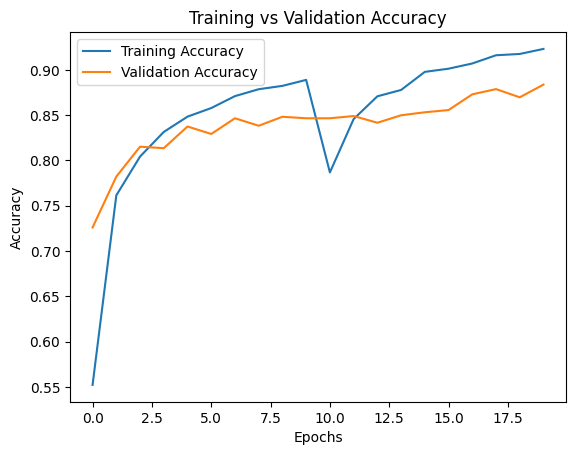

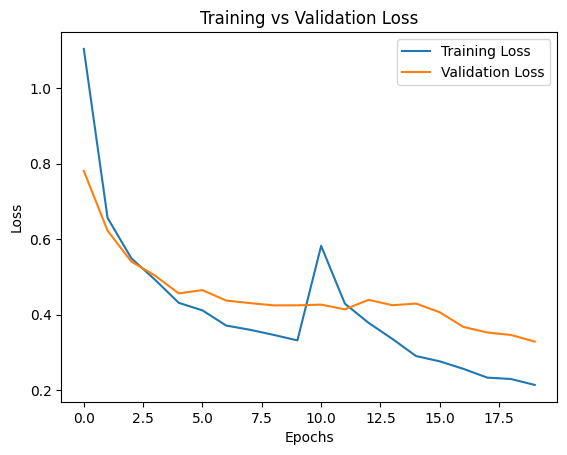

In [ ]:
import matplotlib.pyplot as plt

# Combine both training phases
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure()
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.figure()
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Reset generator (VERY IMPORTANT)
val_generator.reset()

# Predict
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step


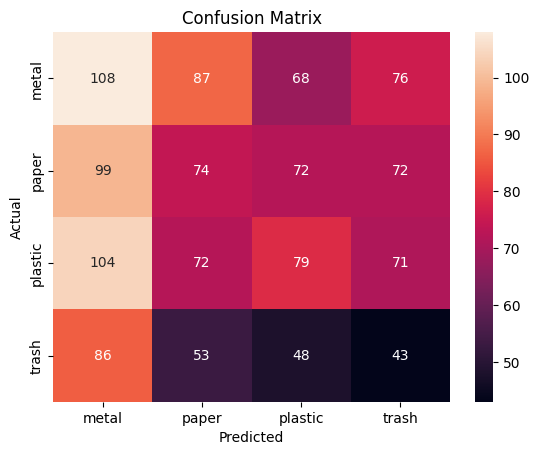

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.27      0.32      0.29       339
       paper       0.26      0.23      0.25       317
     plastic       0.30      0.24      0.27       326
       trash       0.16      0.19      0.17       230

    accuracy                           0.25      1212
   macro avg       0.25      0.25      0.25      1212
weighted avg       0.25      0.25      0.25      1212



In [ ]:
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # ✅ ADD THIS LINE
)

Found 1212 images belonging to 4 classes.


In [ ]:
val_generator.reset()

In [ ]:
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

print(classification_report(y_true, y_pred_classes))

[[327   3   3   6]
 [ 21 275   6  15]
 [ 35   3 252  36]
 [ 11   4  11 204]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       339
           1       0.96      0.87      0.91       317
           2       0.93      0.77      0.84       326
           3       0.78      0.89      0.83       230

    accuracy                           0.87      1212
   macro avg       0.88      0.87      0.87      1212
weighted avg       0.88      0.87      0.87      1212



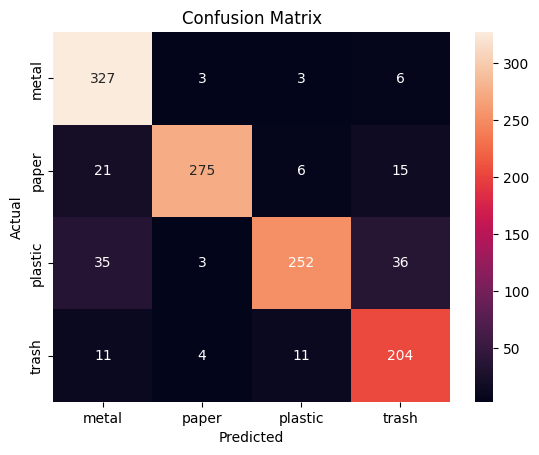

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
rotation_range=30,
zoom_range=0.3,
brightness_range=[0.8,1.2]

In [ ]:
epochs=10  # extra fine-tuning

In [ ]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

In [ ]:
learning_rate=1e-6

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4859 images belonging to 4 classes.
Found 1212 images belonging to 4 classes.


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 91s 528ms/step - accuracy: 0.4845 - loss: 1.4055 - val_accuracy: 0.7888 - val_loss: 0.6483
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 433ms/step - accuracy: 0.7100 - loss: 0.7893 - val_accuracy: 0.8457 - val_loss: 0.4571
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 432ms/step - accuracy: 0.7707 - loss: 0.6377 - val_accuracy: 0.8589 - val_loss: 0.3969
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 435ms/step - accuracy: 0.8041 - loss: 0.5346 - val_accuracy: 0.8639 - val_loss: 0.3798
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 426ms/step - accuracy: 0.8345 - loss: 0.4831 - val_accuracy: 0.8754 - val_loss: 0.3551
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 65s 430ms/step - accuracy: 0.8333 - loss: 0.4776 - val_accuracy: 0.8804 - val_loss: 0.3423
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 435ms/step - accuracy: 0.8419 - loss: 0.4586 - val_accuracy: 0.8837 - val_loss: 0.3316
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 434ms/step - accuracy: 0.8611 - loss: 0

In [ ]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 124s 597ms/step - accuracy: 0.8059 - loss: 0.5933 - val_accuracy: 0.8845 - val_loss: 0.3336
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 443ms/step - accuracy: 0.8100 - loss: 0.5715 - val_accuracy: 0.8754 - val_loss: 0.3466
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 84s 455ms/step - accuracy: 0.8092 - loss: 0.5868 - val_accuracy: 0.8696 - val_loss: 0.3582
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 456ms/step - accuracy: 0.8160 - loss: 0.5639 - val_accuracy: 0.8705 - val_loss: 0.3652
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 455ms/step - accuracy: 0.8205 - loss: 0.5321 - val_accuracy: 0.8655 - val_loss: 0.3696
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 452ms/step - accuracy: 0.8195 - loss: 0.5432 - val_accuracy: 0.8647 - val_loss: 0.3767
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 441ms/step - accuracy: 0.8255 - loss: 0.5310 - val_accuracy: 0.8655 - val_loss: 0.3777
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 447ms/step - accuracy: 0.8247 - loss: 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 447ms/step - accuracy: 0.8275 - loss: 0.5003 - val_accuracy: 0.8639 - val_loss: 0.3847
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 452ms/step - accuracy: 0.8321 - loss: 0.4955 - val_accuracy: 0.8647 - val_loss: 0.3828
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 444ms/step - accuracy: 0.8395 - loss: 0.5022 - val_accuracy: 0.8622 - val_loss: 0.3848
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 447ms/step - accuracy: 0.8380 - loss: 0.4880 - val_accuracy: 0.8597 - val_loss: 0.3853
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 445ms/step - accuracy: 0.8352 - loss: 0.5008 - val_accuracy: 0.8606 - val_loss: 0.3832


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8647 - loss: 0.3828
Final Validation Accuracy: 0.8646864891052246


In [ ]:
val_generator.reset()

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step


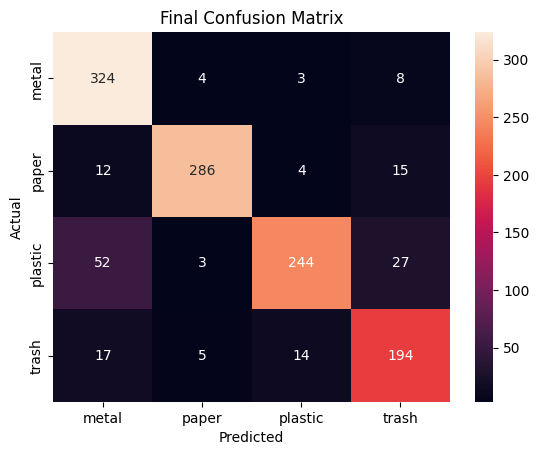

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.80      0.96      0.87       339
       paper       0.96      0.90      0.93       317
     plastic       0.92      0.75      0.83       326
       trash       0.80      0.84      0.82       230

    accuracy                           0.86      1212
   macro avg       0.87      0.86      0.86      1212
weighted avg       0.87      0.86      0.86      1212



In [ ]:
model.save("/content/waste_classifier_final.keras")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving plastic_9.jpg to plastic_9.jpg


In [ ]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction:", class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: plastic


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    zoom_range=0.4,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4]
)

In [ ]:
img_size = 256

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 461ms/step - accuracy: 0.8403 - loss: 0.4760 - val_accuracy: 0.8655 - val_loss: 0.3827
Epoch 2/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 444ms/step - accuracy: 0.8366 - loss: 0.4884 - val_accuracy: 0.8622 - val_loss: 0.3822
Epoch 3/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 448ms/step - accuracy: 0.8354 - loss: 0.4856 - val_accuracy: 0.8606 - val_loss: 0.3800
Epoch 4/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 442ms/step - accuracy: 0.8352 - loss: 0.5168 - val_accuracy: 0.8622 - val_loss: 0.3799
Epoch 5/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - accuracy: 0.8424 - loss: 0.4705 - val_accuracy: 0.8630 - val_loss: 0.3775
Epoch 6/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 440ms/step - accuracy: 0.8446 - loss: 0.4560 - val_accuracy: 0.8647 - val_loss: 0.3767
Epoch 7/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - accuracy: 0.8409 - loss: 0.4739 - val_accuracy: 0.8639 - val_loss: 0.3758
Epoch 8/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 451ms/step - accuracy: 0.8428 - loss: 0

In [ ]:
for layer in base_model.layers[-120:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 130s 607ms/step - accuracy: 0.8485 - loss: 0.4502 - val_accuracy: 0.8779 - val_loss: 0.3206
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 446ms/step - accuracy: 0.8504 - loss: 0.4440 - val_accuracy: 0.8795 - val_loss: 0.3187
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 442ms/step - accuracy: 0.8446 - loss: 0.4540 - val_accuracy: 0.8820 - val_loss: 0.3198
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 454ms/step - accuracy: 0.8483 - loss: 0.4323 - val_accuracy: 0.8779 - val_loss: 0.3244
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 449ms/step - accuracy: 0.8405 - loss: 0.4738 - val_accuracy: 0.8787 - val_loss: 0.3294


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8795 - loss: 0.3187
Final Validation Accuracy: 0.8795379400253296


In [ ]:
val_generator.reset()

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step


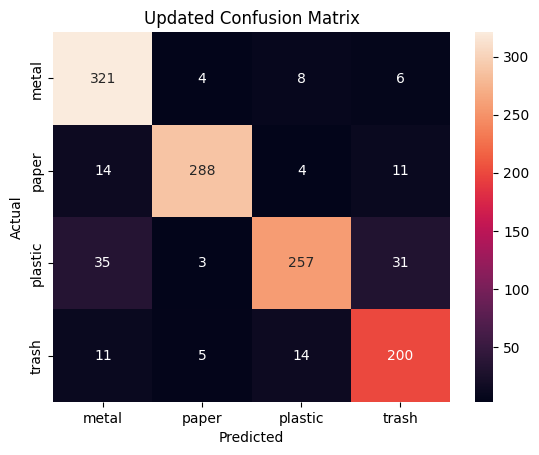

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Updated Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.84      0.95      0.89       339
       paper       0.96      0.91      0.93       317
     plastic       0.91      0.79      0.84       326
       trash       0.81      0.87      0.84       230

    accuracy                           0.88      1212
   macro avg       0.88      0.88      0.88      1212
weighted avg       0.88      0.88      0.88      1212



In [ ]:
model.save("/content/waste_classifier_final.keras")

In [ ]:
from google.colab import files
files.download("/content/waste_classifier_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving waste_classifier_final.keras to waste_classifier_final (1).keras


In [3]:
import zipfile
import os

zip_path = "dataset.zip"  # make sure name matches

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

# Check
print(os.listdir("/content"))

['.config', 'waste_classifier_final.keras', '.ipynb_checkpoints', 'dataset', 'dataset.zip', 'sample_data']


In [4]:
print(os.listdir("/content/dataset"))

['trash', 'paper', 'metal', 'plastic']


In [5]:
dataset_path = "/content/dataset"

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4859 images belonging to 4 classes.
Found 1212 images belonging to 4 classes.


In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.8931985294117647), 1: np.float64(0.9557435090479937), 2: np.float64(0.9287079510703364), 3: np.float64(1.3203804347826087)}


In [8]:
import tensorflow as tf

model = tf.keras.models.load_model("waste_classifier_final.keras")

In [9]:
model.evaluate(val_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 372ms/step - accuracy: 0.8795 - loss: 0.3187


[0.3187416195869446, 0.8795379400253296]

In [10]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 74s 277ms/step - accuracy: 0.8850 - loss: 0.3414 - val_accuracy: 0.8812 - val_loss: 0.3113
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.8823 - loss: 0.3408 - val_accuracy: 0.8853 - val_loss: 0.3101
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8874 - loss: 0.3296 - val_accuracy: 0.8828 - val_loss: 0.3105
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.8870 - loss: 0.3372 - val_accuracy: 0.8779 - val_loss: 0.3130
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.8930 - loss: 0.3271 - val_accuracy: 0.8837 - val_loss: 0.3161


In [11]:
model.save("/content/waste_classifier_v2.keras")

In [12]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8837 - loss: 0.3161
Validation Accuracy: 0.8836633563041687


In [13]:
val_generator.reset()

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step


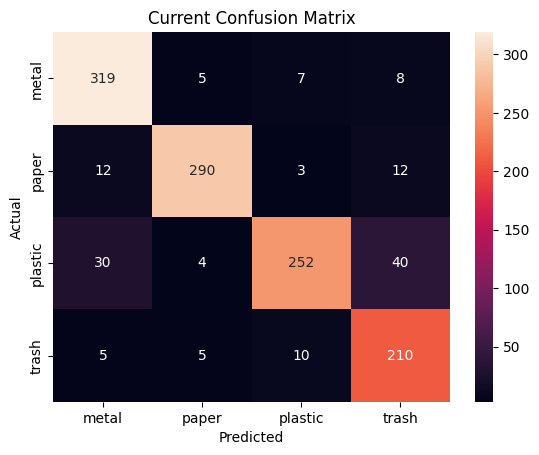

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Current Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.8870 - loss: 0.3280 - val_accuracy: 0.8837 - val_loss: 0.3208
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.8942 - loss: 0.3197 - val_accuracy: 0.8845 - val_loss: 0.3223
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8983 - loss: 0.3045 - val_accuracy: 0.8812 - val_loss: 0.3270
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8973 - loss: 0.2917 - val_accuracy: 0.8812 - val_loss: 0.3317
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.8983 - loss: 0.3036 - val_accuracy: 0.8795 - val_loss: 0.3371


In [16]:
model.evaluate(val_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8795 - loss: 0.3371


[0.3370727300643921, 0.8795379400253296]

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-7),  # VERY LOW
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
for layer in model.layers[:-20]:
    layer.trainable = False

In [19]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    class_weight=class_weights_dict
)

Epoch 1/3
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.9039 - loss: 0.2669 - val_accuracy: 0.8787 - val_loss: 0.3385
Epoch 2/3
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9115 - loss: 0.2623 - val_accuracy: 0.8771 - val_loss: 0.3398
Epoch 3/3
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9055 - loss: 0.2747 - val_accuracy: 0.8779 - val_loss: 0.3403


In [20]:
model.evaluate(val_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8779 - loss: 0.3403


[0.3403201103210449, 0.8778877854347229]

In [21]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-7),
    loss=loss_fn,
    metrics=['accuracy']
)

In [22]:
model.evaluate(val_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.8779 - loss: 0.8032


[0.8031601309776306, 0.8778877854347229]

In [23]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8779 - loss: 0.8032
Validation Accuracy: 0.8778877854347229


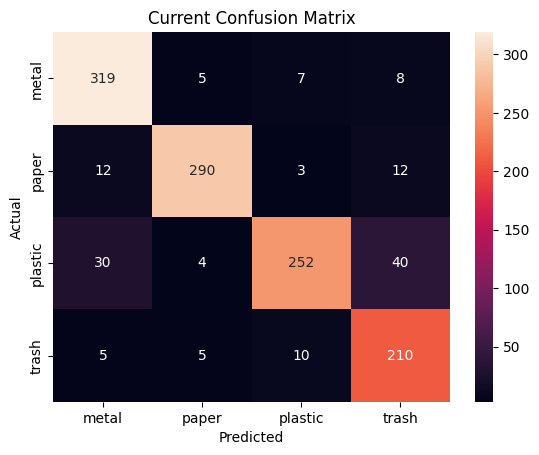

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Current Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
from tensorflow.keras.applications import EfficientNetB0

In [26]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
for layer in base_model.layers:
    layer.trainable = False

In [28]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 266ms/step - accuracy: 0.2655 - loss: 1.5118 - val_accuracy: 0.2616 - val_loss: 1.3897
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.2554 - loss: 1.4582 - val_accuracy: 0.2731 - val_loss: 1.3848
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.2643 - loss: 1.4368 - val_accuracy: 0.2616 - val_loss: 1.3841
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.2597 - loss: 1.4280 - val_accuracy: 0.2145 - val_loss: 1.3838
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.2750 - loss: 1.4130 - val_accuracy: 0.1972 - val_loss: 1.3831
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.2832 - loss: 1.4106 - val_accuracy: 0.1955 - val_loss: 1.3849
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.2636 - loss: 1.4121 - val_accuracy: 0.2054 - val_loss: 1.3845
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.2719 - loss: 1.4122 -

In [31]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 90s 305ms/step - accuracy: 0.2581 - loss: 1.6475 - val_accuracy: 0.2616 - val_loss: 1.4383
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.2682 - loss: 1.5787 - val_accuracy: 0.2607 - val_loss: 1.4194
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.2830 - loss: 1.5096 - val_accuracy: 0.1980 - val_loss: 1.5525
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.3013 - loss: 1.4941 - val_accuracy: 0.2104 - val_loss: 1.4114
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.2951 - loss: 1.4786 - val_accuracy: 0.2063 - val_loss: 1.4797
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3050 - loss: 1.4499 - val_accuracy: 0.1988 - val_loss: 1.4214
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3114 - loss: 1.4258 - val_accuracy: 0.2228 - val_loss: 1.4057
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3340 - loss: 1.4079 -

In [34]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.2079 - loss: 1.4356
Validation Accuracy: 0.20792078971862793


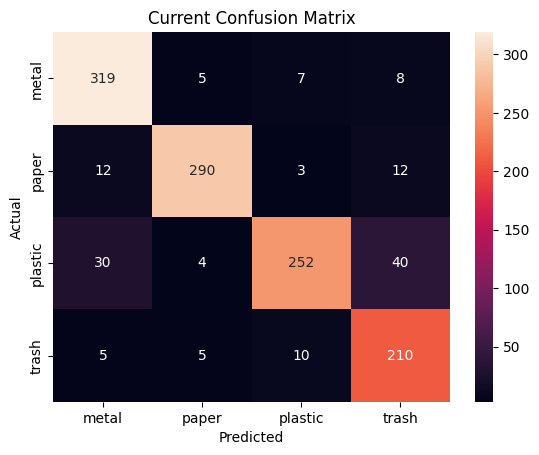

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Current Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [37]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [38]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4859 images belonging to 4 classes.
Found 1212 images belonging to 4 classes.


In [39]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.2894 - loss: 1.5826 - val_accuracy: 0.3729 - val_loss: 1.3143
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.3830 - loss: 1.3661 - val_accuracy: 0.5363 - val_loss: 1.1578
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.4906 - loss: 1.1819 - val_accuracy: 0.6320 - val_loss: 1.0460
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.5565 - loss: 1.0537 - val_accuracy: 0.6782 - val_loss: 0.9531
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.6044 - loss: 0.9584 - val_accuracy: 0.7129 - val_loss: 0.8727
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6602 - loss: 0.8672 - val_accuracy: 0.7376 - val_loss: 0.8031
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7006 - loss: 0.7778 - val_accuracy: 0.7566 - val_loss: 0.7453
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7158 - loss: 0.7386 - 

In [40]:
model.evaluate(val_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8012 - loss: 0.6075


[0.6074978709220886, 0.8011550903320312]

In [41]:
for layer in model.layers[-150:]:
    layer.trainable = True

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 101s 340ms/step - accuracy: 0.7866 - loss: 0.5856 - val_accuracy: 0.8152 - val_loss: 0.5571
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.7936 - loss: 0.5547 - val_accuracy: 0.8284 - val_loss: 0.5136
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.8224 - loss: 0.4921 - val_accuracy: 0.8416 - val_loss: 0.4765
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.8409 - loss: 0.4546 - val_accuracy: 0.8556 - val_loss: 0.4438
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.8487 - loss: 0.4225 - val_accuracy: 0.8622 - val_loss: 0.4151
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8619 - loss: 0.4007 - val_accuracy: 0.8680 - val_loss: 0.3936
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8666 - loss: 0.3803 - val_accuracy: 0.8705 - val_loss: 0.3814
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8780 - loss: 0.3496 

In [44]:
model.evaluate(val_generator)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8870 - loss: 0.3300


[0.3299838900566101, 0.8869637250900269]

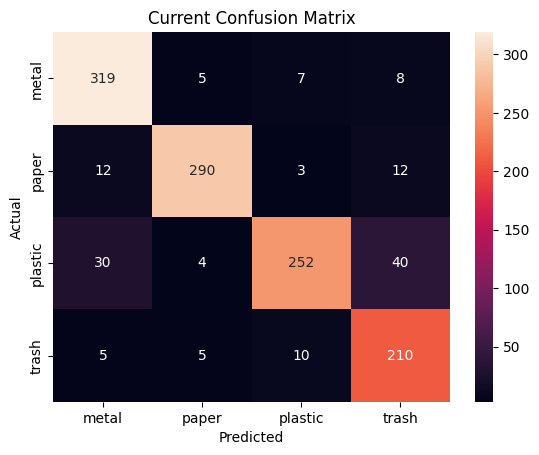

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Current Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
from google.colab import files
files.download("/content/waste_classifier_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>